# Parameter tuning Narrabeen

## Paths and settings

In [1]:
new_initial_state = True
new_tuning = True

In [2]:
# paths jupyter utwente
path_tc = '/home/jovyan/data/98_paper2_kf_dtm/01_tides/output/'
path_validation = '/home/jovyan/data/98_paper2_kf_dtm/03_Narrabeen_validation_data/'

path_input_general = '/home/jovyan/data/98_paper2_kf_dtm/0_input_general/'
path_input = '/home/jovyan/data/98_paper2_kf_dtm/32_33_Narrabeen_DEM/input/'
path_output = '/home/jovyan/data/98_paper2_kf_dtm/32_33_Narrabeen_DEM/output/'
path_altimetry_output = '/home/jovyan/data/98_paper2_kf_dtm/31_Narra_altimetry/output/'

# filenames for gebco and DeltaDTM
fn_gebco = 'gebco_2024_n-33.6_s-33.8_w151.2_e151.4.nc'
fn_ddtm = 'DeltaDTM_v1_0_S34E151.tif'

epsg = 4326 # WGS84
epsg_local = 32356

year_start = 1993
year_end = 2020 # included

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Imports

In [3]:
%load_ext autoreload
%autoreload 2

import pdb

import os
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
import time
import itertools

from scipy import stats

from shapely import LineString

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import colormaps as cm
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from coastal_data import CD_statistics, CD_combine_data, \
    CD_geometry, CD_kalman, CD_visualisation

/home/jovyan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Static parameters

In [5]:
# Define T as identity matrix or with spatial dependencies
T_is_identity = True # Use identity matrix
# T_is_identity = False # Model spatial dependencies

# T-matrix with spatial dependencies
# if not T_is_identity:
# All points within `max_distance` around the point of iterest (identitcal point)
# are considered neighbouring points
max_distance = 150

# Weight of the identical point in T
# (residual weight is equally distributed between neighbouring points)
w_id = 0.5

# Number of iterations where a grid point does not get updated in a row
# before infusing a pseudo observation from the initial state
max_noupdate = 5

# Standard deviation of pseudo-observations
std_pseudobs = 1 # [m]

# eps: parameter in function 'sparsify matrix'
# smallest absolute value allowed in a sparse matrix
# eps = mean(diag) / eps_factor
# only important if using T with spatial averaging
eps_factor = 1e9

## Observations

In [6]:
# Altimetry
fn = 'tp_plus_ales_epsg32356.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])

In [7]:
# Tidal correction
fn = 'tides_narra.csv'
tidal_corr = pd.read_csv(path_tc+fn, index_col='dates', parse_dates=['dates'])

In [8]:
# Cassie shorelines
folders = ['2_1992-09-24_1998-04-18_spac100_ext400_thresh0/',
          '3_1998-05-20_2007-09-18_spac100_ext400_thresh0/',
          '4_2007-10-04_2016-10-28_spac100_ext400_thresh0/',
          '5_2016-11-13_2021-10-26_spac100_ext400_thresh0/']
sl_cassie = CD_combine_data.combine_cassie(path_input+'1_shorelines_cassie/', folders, epsg=epsg)

# Reduce shorelines to the altimetry period
idx, = np.where((np.array(sl_cassie['dates']) >= alt.index[0]) & (np.array(sl_cassie['dates']) <= alt.index[-1]))

c_dates = np.array(sl_cassie['dates'], dtype=object)[idx]
c_shorelines = np.array(sl_cassie['shorelines'], dtype=object)[idx]

# number of points per shoreline
n_sl_points = np.array([len(_) for _ in c_shorelines])
print(f"{len(c_shorelines)} Landsat/Cassie shorelines in total in the altimetry period. "
    f"Shorelines have on average {int(np.nanmean(n_sl_points))} points (min: {np.nanmin(n_sl_points)}, max: {np.nanmax(n_sl_points)}).")

263 Landsat/Cassie shorelines in total in the altimetry period. Shorelines have on average 115 points (min: 34, max: 143).


## Validation data

In [9]:
vali_gdf_orig = gpd.read_file(path_validation + 'narrabeen_profiles_with_coords.geojson')
vali_gdf_orig = vali_gdf_orig.set_index('date')

# Reduce to time after 1993
idx, = np.where(vali_gdf_orig.index.year >= year_start)
vali_gdf_orig = vali_gdf_orig.iloc[idx]

# yearly means anchored in June
# https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
vali_df_mean = vali_gdf_orig.drop(columns=['profile']).groupby([pd.Grouper(freq='YE-JUN'), 'geometry']).mean()

vali_years = vali_df_mean.reset_index('geometry').index.year
vali_df_mean = vali_df_mean.droplevel(0).reset_index()
vali_df_mean.index = vali_years

# Change format so that years are the columns and rows the unique point geometries
# (that format is expected by the compute_volume function)
vali_df = vali_df_mean.pivot_table(index='geometry', columns='date', values='elev', aggfunc='first')
vali_df = vali_df.reset_index()
vali_gdf = gpd.GeoDataFrame(vali_df, geometry='geometry')

vali_gdf.columns = [str(_) for _ in vali_gdf.columns]
vali_gdf = vali_gdf.drop(columns=['2000', '2001', '2002', '2012'], errors='ignore') # no Cassie shorelines available in these years

vali_gdf.to_file(path_output + 'narra_vali_gdf.geojson')

### Map

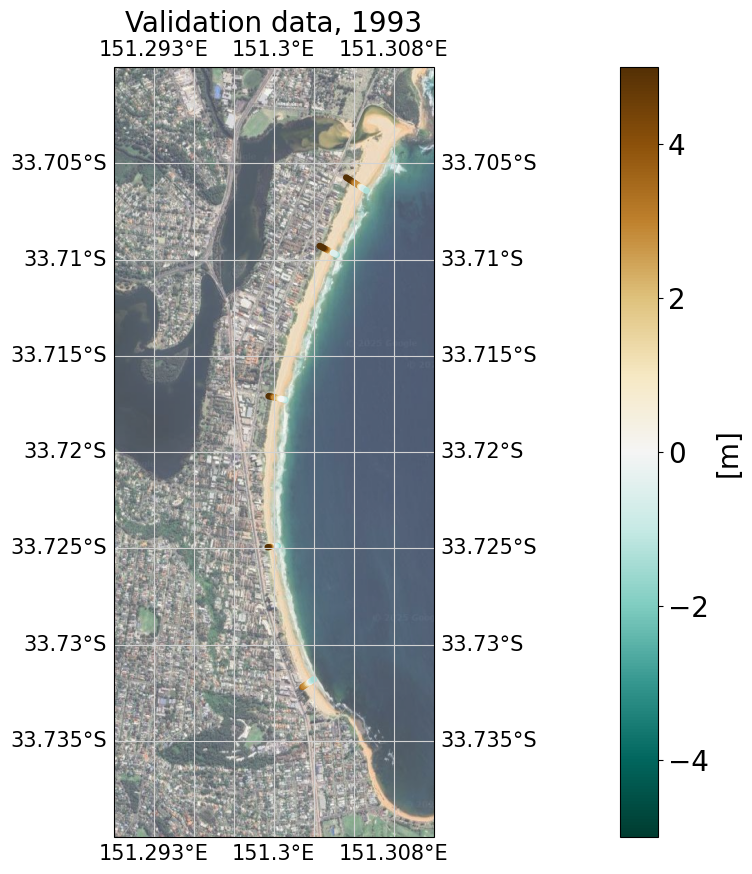

In [10]:
year = '1993'

extent = [151.29, 151.31, -33.74, -33.70]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

plot = ax.scatter(vali_gdf.geometry.x, vali_gdf.geometry.y, c=vali_gdf[year],
                  transform=ccrs.PlateCarree(), marker='.', s=50, cmap='BrBG_r', vmin=-5, vmax=5)
fig.colorbar(plot, shrink=1, pad=0.12, label='[m]')
ax.set_title(f'Validation data, {year}');

## Initial state

In [39]:
resolution_m = 50 # [m], resolution of the target grid in x- and y-direction
fn_init = f'init_{epsg}_resolution_{resolution_m}m.tif'
if (not os.path.isfile(path_output + fn_init)) | new_initial_state:
    buffer_size = 500 # [m], buffer radius of target area around the set of shorelines
    if epsg == 4326:
        buffer_size = CD_geometry.dist_meter_to_dist_deg(buffer_size) # [deg]
        resolution_deg = CD_geometry.dist_meter_to_dist_deg(resolution_m) # [deg]

    smooth_factor = 100 # Smoothing of shorelines used to compute the median shoreline

    # Target area
    # alpha (how much slack around the concave hull)
    if epsg == 4326:
        alpha = 100
    elif epsg == 28992:
        alpha = 3e-4    

    # Buffer around median shoreline
    med_sl = CD_geometry.median_shoreline_from_transect_intersections(c_shorelines, spacing=50,
                                                                      transect_length=5000, smooth_factor=50)
    poly_target = med_sl.buffer(buffer_size)
    # Polgon around the shorelines
    poly_shorelines = CD_geometry.get_area_covered_by_shorelines(c_shorelines, alpha=alpha, buffer_size=0)

    pickle.dump(med_sl, open(path_output + f'med_sl{epsg}.pkl', 'wb'))
    pickle.dump(poly_target, open(path_output + f'poly_target{epsg}.pkl', 'wb'))
    pickle.dump(poly_shorelines, open(path_output + f'poly_sl_{epsg}.pkl', 'wb'))

    CD_kalman.initial_state(poly_target, med_sl, epsg, resolution_deg, c_shorelines, alt,
                            path_input+'2_global_DEMs/', path_output, fn_init, fn_gebco, fn_ddtm)
else:
    med_sl = pickle.load(open(path_output + f'med_sl{epsg}.pkl', 'rb')) 
    poly_target = pickle.load(open(path_output + f'poly_target{epsg}.pkl', 'rb')) 
    poly_shorelines = pickle.load(open(path_output + f'poly_sl_{epsg}.pkl', 'rb'))

Bias GEBCO - DeltaDTM: 10.04 m (based on 685 overlapping points (interpolated to target grid))
Done. Needed  0.13 minutes.


Always load `init`, even if it was computed in this go (otherwise there is one case where init is a dataframe, and one case where it is an xarray DataSet):

In [12]:
init = xr.open_dataset(path_output+fn_init).squeeze()

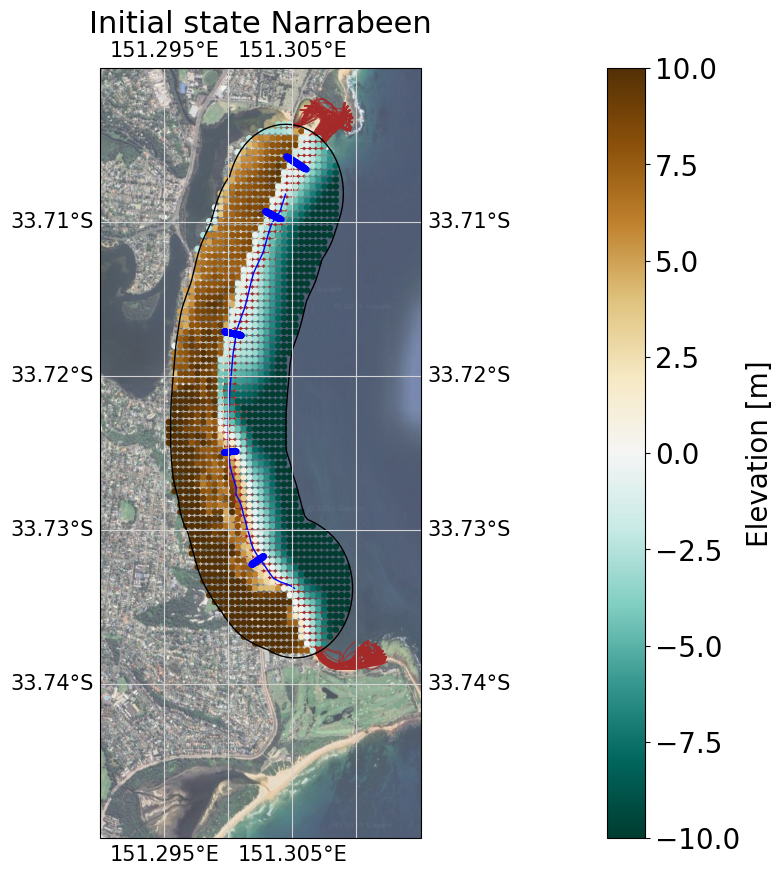

In [13]:
# Plot intial state
init_df = init.to_dataframe()
x = init_df.index.get_level_values('x')
y = init_df.index.get_level_values('y')

projection = ccrs.PlateCarree()
extent = [151.29, 151.315, -33.75, -33.70]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

for sl in c_shorelines:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='brown', zorder=1, alpha=.7)
    
ax.add_geometries(poly_target, crs=projection, facecolor='none', edgecolor='black')
ax.add_geometries(med_sl, crs=projection, facecolor='none', edgecolor='blue')
    
plot = ax.scatter(x, y, c=init_df.band_data, transform=projection, marker='.', s=50,
                  cmap='BrBG_r', vmin=-10, vmax=10)

# Validation data
ax.scatter(vali_gdf.geometry.x, vali_gdf.geometry.y, c='blue',
                transform=ccrs.PlateCarree(), marker='.', s=50)

fig.colorbar(plot, shrink=1, pad=0.12, label='Elevation [m]')
ax.set_title('Initial state Narrabeen', fontsize=22);

# plt.savefig(f'{path_partun}initial_state.png', dpi=300, bbox_inches='tight')

## Shoreline outlier rejection

In [14]:
t_factor = 1 # threshold = t_factor * mean, (mean of distances to reference shoreline), points inside that range are kept7
c_shorelines_corr = CD_geometry.shoreline_outlier_rejection(c_shorelines, med_sl, epsg, t_factor)

pickle.dump(c_shorelines_corr, open(path_output + 'c_shorelines_corr.pkl', 'wb'))

37.0% of shoreline points were discarded.


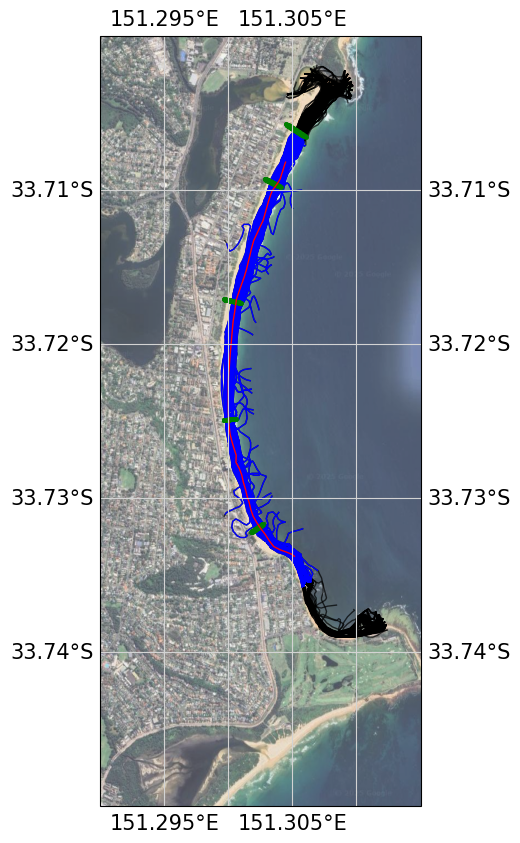

In [15]:
# Visual inspection of shoreline outlier rejection
projection = ccrs.PlateCarree()
extent = [151.29, 151.315, -33.75, -33.70]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

ax.add_geometries(med_sl, crs=projection, facecolor='none', edgecolor='red')

for sl in c_shorelines:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='black', zorder=1, alpha=.7)
for sl in c_shorelines_corr:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='blue', zorder=1, alpha=1)
    
# Validation data
ax.scatter(vali_gdf.geometry.x, vali_gdf.geometry.y, c='green',
                transform=ccrs.PlateCarree(), marker='.', s=25)

In [16]:
poly_sl_corr = CD_geometry.get_area_covered_by_shorelines(c_shorelines_corr, alpha=100, buffer_size=0)

## Function for volume changes

In [17]:
def volume_changes(x_state, x_state_s, vali_gdf, area_polys):
    start_time = time.perf_counter()

    year_list = [int(_) for _ in kf_interp.drop(columns='geometry').columns]

    volumes = pd.DataFrame(index=year_list)
    rmse = {}
    corr = {}
    pvalues = {}
    trends = {}
    
    for area in area_polys.keys():
        volumes[f'rts_{area}'] = CD_geometry.compute_volume_changes(x_state_s, area_polys[area], col_name='', epsg_out=epsg_local)
        volumes[f'vali_{area}'] = CD_geometry.compute_volume_changes(vali_gdf, area_polys[area], col_name='', epsg_out=epsg_local)
        
        rmse[area] = CD_statistics.RMSE_timeseries(volumes[f'rts_{area}'], volumes[f'vali_{area}'])
        corr[area], pvalues[area] = stats.pearsonr(volumes[f'rts_{area}'], volumes[f'vali_{area}'])

        trends[f'rts_{area}'], _, _ = CD_statistics.compute_trend_with_error(volumes.index.values.astype(int),
                                                                        volumes[f'rts_{area}'].values)
        trends[f'vali_{area}'], _, _ = CD_statistics.compute_trend_with_error(volumes.index.values.astype(int),
                                                                        volumes[f'vali_{area}'].values)

    end_time = time.perf_counter()
    ex_time = end_time - start_time
    print("Volume changes done. Needed ", round(ex_time,1), "seconds.")
       
    return volumes, rmse, corr, pvalues, trends

## Define area for volume change

In [18]:
buffer_vol = -450 # [m]
buffer_vol = CD_geometry.dist_meter_to_dist_deg(buffer_vol)
poly_target_red = poly_target.buffer(buffer_vol)
print(f'Reduced target polygon by {round(1-(poly_target_red.area / poly_target.area), 3)*100} %')
pickle.dump(poly_target_red, open(path_output + f'poly_target_red_{epsg}.pkl', 'wb'))

Reduced target polygon by 91.7 %


### Buffer around the profiles

In [19]:
if not os.path.isfile(path_output + 'profile_polys.pkl'):
    profile_polys = {}
    profile_names = np.unique(vali_gdf_orig['profile'])
    for profile in profile_names:
        # profile = profile_names[0]
        idx_pf, = np.where(vali_gdf_orig['profile'] == profile)
        vali_pf = vali_gdf_orig.iloc[idx_pf]

        pf = LineString(vali_pf.geometry)
        bs = CD_geometry.dist_meter_to_dist_deg(50) # buffer size
        profile_polys[profile] = pf.buffer(bs)

    pickle.dump(profile_polys, open(path_output + 'profile_polys.pkl', 'wb'))
else:
    profile_polys = pickle.load(open(path_output + 'profile_polys.pkl', 'rb'))

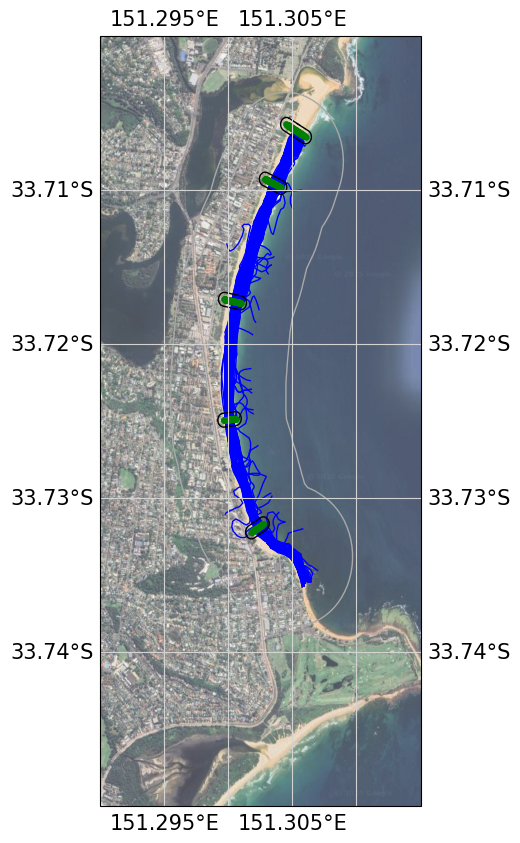

In [20]:
# Visualise volume change areas
projection = ccrs.PlateCarree()
extent = [151.29, 151.315, -33.75, -33.70]
# extent = [151.29, 151.315, -33.71, -33.70] # zoom to profile 1
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

# ax.add_geometries(poly_sl_corr, crs=projection, facecolor='none', edgecolor='orange')
ax.add_geometries(poly_target, crs=projection, facecolor='none', edgecolor='darkgrey')

ax.add_geometries(profile_polys['PF1'], crs=projection, facecolor='none', edgecolor='black')
ax.add_geometries(profile_polys['PF2'], crs=projection, facecolor='none', edgecolor='black')
ax.add_geometries(profile_polys['PF4'], crs=projection, facecolor='none', edgecolor='black')
ax.add_geometries(profile_polys['PF6'], crs=projection, facecolor='none', edgecolor='black')
ax.add_geometries(profile_polys['PF8'], crs=projection, facecolor='none', edgecolor='black')

for sl in c_shorelines_corr:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='blue', zorder=1, alpha=1)
    
# Validation data
ax.scatter(vali_gdf.geometry.x, vali_gdf.geometry.y, c='green',
                transform=ccrs.PlateCarree(), marker='.', s=50)

## Tune

### Parameters

In [21]:
# sigma_l
# Minimum combined error
beach_slope_min = 0.001
rmse_h_cassie_min = 5
std_alt_min = 0.03
rms_eot20_min = 0.01 # from paper, table 3: 0.061
sigma_v_total_min = np.sqrt((beach_slope_min * rmse_h_cassie_min)**2 + std_alt_min**2 + rms_eot20_min**2)

# Maximum combined error
beach_slope_max = 0.02
rmse_h_cassie_max = 50
std_alt_max = .8
rms_eot20_max = 0.1
sigma_v_total_max = np.sqrt((beach_slope_max * rmse_h_cassie_max)**2 + std_alt_max**2 + rms_eot20_max**2)

print(f'Min: {round(sigma_v_total_min,2)} m, Max: {round(sigma_v_total_max,2)} m')

Min: 0.03 m, Max: 1.28 m


In [22]:
sigma_l_values =  np.linspace(sigma_v_total_min, sigma_v_total_max, 5) # [m]
factors = [1, 10, 25]
std_init_values = [1, 3, 9] # [m]

param_df = pd.DataFrame(list(itertools.product(factors, sigma_l_values, std_init_values)), columns=['factor', 'sigma_l', 'std_init'])

param_df['sigma_q'] = param_df['factor'] * param_df['sigma_l']
param_df

,factor,sigma_l,std_init,sigma_q
0,1,0.032016,1,0.032016
1,1,0.032016,3,0.032016
2,1,0.032016,9,0.032016
3,1,0.345143,1,0.345143
4,1,0.345143,3,0.345143
5,1,0.345143,9,0.345143
6,1,0.658269,1,0.658269
7,1,0.658269,3,0.658269
8,1,0.658269,9,0.658269
9,1,0.971396,1,0.971396


### Get beach slope from validation data

In [23]:
all_slopes = np.empty(0)
profile_names = np.unique(vali_gdf_orig['profile'])
for profile in profile_names:
    idx_pf, = np.where(vali_gdf_orig['profile'] == profile)
    vali_pf = vali_gdf_orig.iloc[idx_pf]

    slopes_averaged = vali_pf.slope.groupby(pd.Grouper(freq='YE')).mean().values
    all_slopes = np.concatenate([all_slopes, slopes_averaged])

In [24]:
print('Beach slope statistics (all_slopes contains one average beach slope per profile and per year, so the mean of one measurement line)')
print(f'Mean beach slope: {np.nanmean(all_slopes)}')
print(f'Median beach slope: {np.nanmedian(all_slopes)}')
print(f'Minimum beach slope: {np.nanmin(np.abs(all_slopes))}')
print(f'Maximum beach slope: {np.nanmax(np.abs(all_slopes))}')

Beach slope statistics (all_slopes contains one average beach slope per profile and per year, so the mean of one measurement line)
Mean beach slope: 0.10362933806648474
Median beach slope: 0.10498019801980198
Minimum beach slope: 0.045512820512820504
Maximum beach slope: 0.20732235294117646


### Single run

In [25]:
i = 4
factor = param_df.loc[i, 'factor']
sigma_q = param_df.loc[i, 'sigma_q']
sigma_l = param_df.loc[i, 'sigma_l']
std_init = param_df.loc[i, 'std_init']
print(f'{i}: factor = {factor}, sigma_l = {sigma_l}, std_init = {std_init}')

rs_shoreline = {"dates":c_dates, "shorelines":c_shorelines_corr}
seg_length = 50 # [m]
seg_length = CD_geometry.dist_meter_to_dist_deg(seg_length) # [deg]

x_state, sigma_xx_up, sigma_xx_pred, updated_points, T = CD_kalman.forward_run(
    year_start, year_end, init, std_init, rs_shoreline, seg_length, alt,
    tidal_corr['corr_eot[m]'], epsg, T_is_identity, max_distance, w_id,
    max_noupdate, std_pseudobs, sigma_l, sigma_q, eps_factor)
        
x_state_s, sigma_xx_s = CD_kalman.backward_run(x_state, sigma_xx_up, sigma_xx_pred, year_end, T, eps_factor)       

kf_interp, rts_interp = CD_kalman.interpolate_results(vali_gdf, x_state, x_state_s, updated_points)

# Volume change time series
volumes, rmse, corr, pvalues, trends = volume_changes(kf_interp, rts_interp, vali_gdf, profile_polys)

4: factor = 1, sigma_l = 0.3451425303570014, std_init = 3
Forward run done. Needed  5.1 seconds.
Backward run done. Needed  0.7 seconds.
Interpolation done. Needed  1.3 seconds.
Volume changes done. Needed  0.6 seconds.


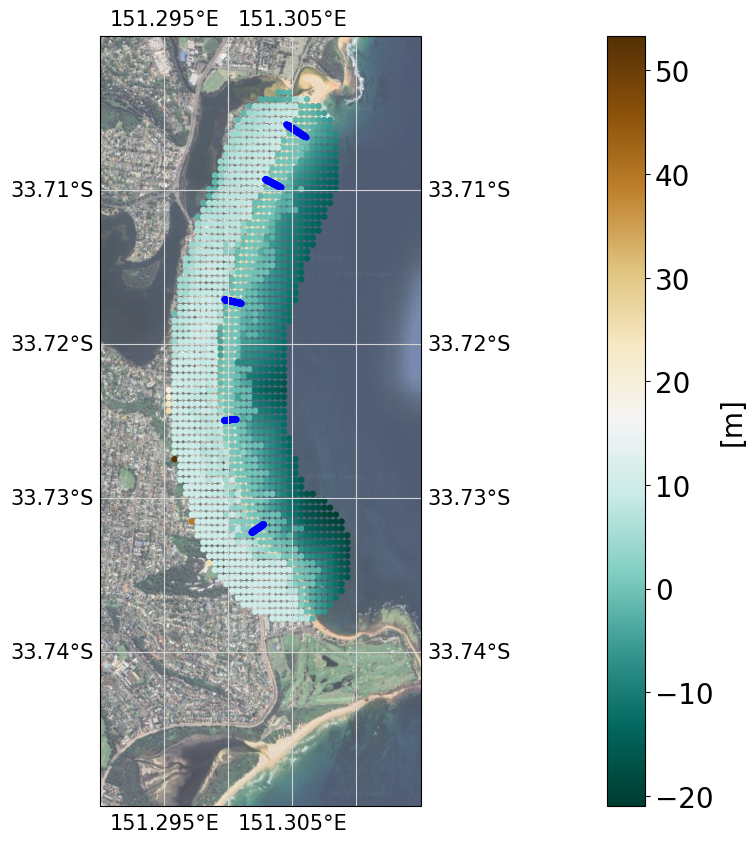

In [26]:
projection = ccrs.PlateCarree()
extent = [151.29, 151.315, -33.75, -33.70]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

# RTS-DTM
plot = ax.scatter(x_state_s.geometry.x, x_state_s.geometry.y, c=x_state_s['x_s_1993'], #-x_state['init'],
                  transform=projection, marker='.', s=50, cmap='BrBG_r') #, vmin=-8, vmax=8)

# Validation data
ax.scatter(vali_gdf.geometry.x, vali_gdf.geometry.y, c='blue',
                transform=ccrs.PlateCarree(), marker='.', s=50)

# # RTS DTM interpolated to validation grid
# plot = ax.scatter(rts_interp.geometry.x, rts_interp.geometry.y, c=rts_interp['1993'], #-x_state['init'],
#                   transform=projection, marker='.', s=50, cmap='BrBG_r') #, vmin=-8, vmax=8)

fig.colorbar(plot, shrink=1, pad=0.12, label='[m]')
# ax.set_title(f'RTS-DEM 2020');

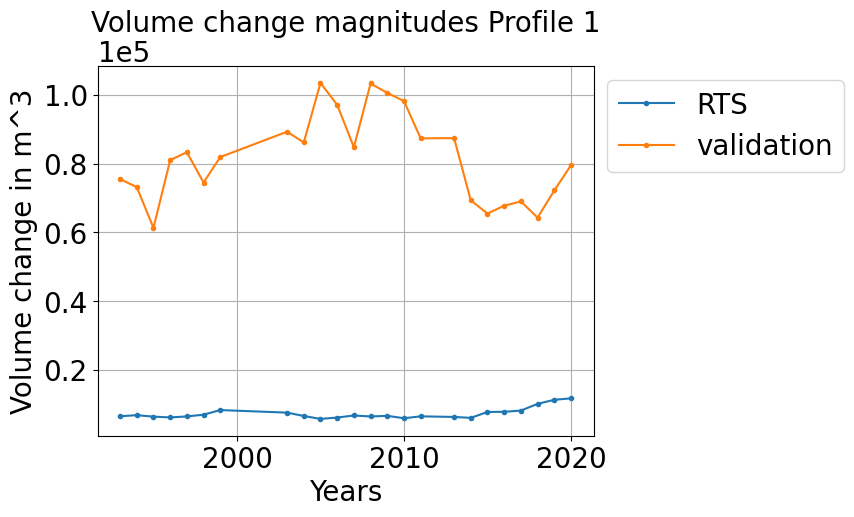

In [27]:
fig, ax = plt.subplots()
# ax.plot(volumes['kf'], '.-', label='KF')
ax.plot(volumes['rts_PF1'], '.-', label='RTS')
ax.plot(volumes['vali_PF1'], '.-', label='validation')

ax.legend(bbox_to_anchor=(1,1))
ax.set_ylabel('Volume change in m^3')
ax.set_xlabel('Years')
ax.set_title('Volume change magnitudes Profile 1')

ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.grid()

### Loop

In [28]:
if new_tuning:
    rs_shoreline = {"dates":c_dates, "shorelines":c_shorelines_corr}
    seg_length = 50 # [m]
    seg_length = CD_geometry.dist_meter_to_dist_deg(seg_length) # [deg]

    # Store statistics for volume time series in DataFrames
    rmse_df = pd.DataFrame()
    corr_df = pd.DataFrame()
    pvalues_df = pd.DataFrame()
    trend_df = pd.DataFrame()
    errors_df = pd.DataFrame()

    # Store statistics for elevation time series in xarray DataSet
    # Initialise xarray DataSet to store the full map for all statistics and each combination of parameters
    lon = vali_gdf.geometry.x
    lat = vali_gdf.geometry.y
    
    empty_array = np.full([len(lon), len(sigma_l_values), len(factors), len(std_init_values)], np.nan)
    
    # Initialise the stats (collect all maps for all parameters) with NaN values
    all_stats = xr.Dataset(
                data_vars={
                    'std_diff':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy()),
                    'rmse':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy()),
                    'corr':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy()),
                    'pvalue':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy()),
                    'trend_diff':(['lon', 'sigma_l', 'factors', 'std_init'], empty_array.copy())
                },
                coords={
                    'lon':(['lon'], lon),
                    'lat':(['lat'], lat),
                    'sigma_l':(['sigma_l'], sigma_l_values),
                    'factors':(['factors'], factors),
                    'std_init':(['std_init'], std_init_values)
                })
    
    for i in param_df.index:
        factor = param_df.loc[i, 'factor']
        sigma_q = param_df.loc[i, 'sigma_q']
        sigma_l = param_df.loc[i, 'sigma_l']
        std_init = param_df.loc[i, 'std_init']
        print(f'{i}: factor = {factor}, sigma_l = {sigma_l}, std_init = {std_init}')

        x_state, sigma_xx_up, sigma_xx_pred, updated_points, T = CD_kalman.forward_run(
            year_start, year_end, init, std_init, rs_shoreline, seg_length, alt,
            tidal_corr['corr_eot[m]'], epsg, T_is_identity, max_distance, w_id,
            max_noupdate, std_pseudobs, sigma_l, sigma_q, eps_factor)

        x_state_s, sigma_xx_s = CD_kalman.backward_run(x_state, sigma_xx_up, sigma_xx_pred, year_end, T, eps_factor)       

        kf_interp, rts_interp = CD_kalman.interpolate_results(vali_gdf, x_state, x_state_s, updated_points)

        # Volume change time series
        volumes, rmse, corr, pvalues, trends = volume_changes(kf_interp, rts_interp, vali_gdf, profile_polys)
        
        rmse_df[i] = pd.DataFrame([rmse]).T[0]
        corr_df[i] = pd.DataFrame([corr]).T[0]
        pvalues_df[i] = pd.DataFrame([pvalues]).T[0]
        trend_df[i] = pd.DataFrame([trends]).T[0]

        # Elevation change timeseries
        for vali_point in vali_gdf.index:
            lon = vali_gdf.iloc[vali_point].geometry.x
            rts_ts = rts_interp.drop(columns='geometry').iloc[vali_point]
            idx, = np.where(np.isin(vali_gdf.columns, rts_ts.index)) # where vali years and rts years overlap
            vali_ts = vali_gdf.loc[vali_point].iloc[idx].astype(float)
            
            not_nan = np.logical_or(np.isnan(rts_ts), vali_ts.isna())
            # if number of nan values more than 50 % of the total number of values
            if not_nan.sum() > len(rts_ts)/2: # at least 50 % overlapping non-nan values
                continue
                
            # RMSE
            all_stats['rmse'].loc[{'lon':lon, 'sigma_l':sigma_l, 'factors':factor, 'std_init':std_init}] = \
                CD_statistics.RMSE_timeseries(rts_ts, vali_ts)
            
            # Correlation
            all_stats['corr'].loc[{'lon':lon, 'sigma_l':sigma_l, 'factors':factor, 'std_init':std_init}], \
                all_stats['pvalue'].loc[{'lon':lon, 'sigma_l':sigma_l, 'factors':factor, 'std_init':std_init}] \
                = stats.pearsonr(vali_ts[~not_nan], rts_ts[~not_nan])
            
            # Trend in m/year, Cxx: cov.matrix, v: diff between observations and model
            trend_rts, _, _ = CD_statistics.compute_trend_with_error(rts_ts.index.values.astype(int), rts_ts.values)
            trend_vali, _, _ = CD_statistics.compute_trend_with_error(vali_ts.index.values.astype(int), vali_ts.values)
            
            all_stats['trend_diff'].loc[{'lon':lon, 'sigma_l':sigma_l, 'factors':factor, 'std_init':std_init}] = trend_rts - trend_vali
                
    all_stats.to_netcdf(f'{path_output}partun_elevs_all_stats.nc')

    rmse_df.to_pickle(path_output+'partun_volumes_rmse.pkl')
    corr_df.to_pickle(path_output+'partun_volumes_corr.pkl')
    pvalues_df.to_pickle(path_output+'partun_volumes_pvalues.pkl')
    trend_df.to_pickle(path_output+'partun_volumes_trends.pkl')
        
else:
    rmse_df = pd.read_pickle(path_output+'partun_volumes_rmse.pkl')
    corr_df = pd.read_pickle(path_output+'partun_volumes_corr.pkl')
    pvalues_df = pd.read_pickle(path_output+'partun_volumes_pvalues.pkl')
    trend_df = pd.read_pickle(path_output+'partun_volumes_trends.pkl')
    print("Loaded files.")

    all_stats = xr.open_dataset(f'{path_output}partun_elevs_all_stats.nc')
    print(f'Loaded {path_output}partun_elevs_all_stats.nc')

0: factor = 1, sigma_l = 0.032015621187164243, std_init = 1
Forward run done. Needed  5.0 seconds.
Backward run done. Needed  0.7 seconds.
Interpolation done. Needed  1.4 seconds.
Volume changes done. Needed  0.6 seconds.
1: factor = 1, sigma_l = 0.032015621187164243, std_init = 3
Forward run done. Needed  5.0 seconds.
Backward run done. Needed  0.7 seconds.
Interpolation done. Needed  1.3 seconds.
Volume changes done. Needed  0.6 seconds.
2: factor = 1, sigma_l = 0.032015621187164243, std_init = 9
Forward run done. Needed  5.0 seconds.
Backward run done. Needed  0.7 seconds.
Interpolation done. Needed  1.4 seconds.
Volume changes done. Needed  0.6 seconds.
3: factor = 1, sigma_l = 0.3451425303570014, std_init = 1
Forward run done. Needed  5.0 seconds.
Backward run done. Needed  0.7 seconds.
Interpolation done. Needed  1.4 seconds.
Volume changes done. Needed  0.6 seconds.
4: factor = 1, sigma_l = 0.3451425303570014, std_init = 3
Forward run done. Needed  5.0 seconds.
Backward run done

## Plots

In [29]:
cmap = cm['Blues_r']
c_list = cmap(np.linspace(0,.6,3))
# c_list = ['purple', 'darkblue', 'limegreen'] # encode sigma_q (factors of sigma_l) with colour
ls_list = ['-', '-.', ':'] # encode sigma_gebco with linestyle

In [30]:
def plot_legend(ax, c_list, ls_list, factors, std_init_values):
    legend_elements = [
        Line2D([0], [0], color='none', label='$\\bf{Color: \\sigma_q}$', lw=0, ms=0),  # Subtitle
        
        Line2D([0], [0], color=c_list[0], label=f'$\\sigma_{{q}}$ = {factors[0]}$\\cdot \\sigma_{{obs}}$ m'),
        Line2D([0], [0], color=c_list[1], label=f'$\\sigma_{{q}}$ = {factors[1]}$\\cdot \\sigma_{{obs}}$ m'),
        Line2D([0], [0], color=c_list[2], label=f'$\\sigma_{{q}}$ = {factors[2]}$\\cdot \\sigma_{{obs}}$ m'),

        Line2D([0], [0], color='none', label='', lw=0, ms=0), # dummy for white space
        Line2D([0], [0], color='none', label='$\\bf{Linestyle: \\sigma_{{init}}}$', lw=0, ms=0),  # Subtitle

        Line2D([0], [0], color='grey', ls=ls_list[0], label=f'$\\sigma_{{init}}$ = {std_init_values[0]} m'),
        Line2D([0], [0], color='grey', ls=ls_list[1], label=f'$\\sigma_{{init}}$ = {std_init_values[1]} m'),
        Line2D([0], [0], color='grey', ls=ls_list[2], label=f'$\\sigma_{{init}}$ = {std_init_values[2]} m'),

        Line2D([0], [0], color='none', label='', lw=0, ms=0), # dummy for white space

        # Line2D([0], [0], marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')
    ]
    ax.legend(handles=legend_elements, bbox_to_anchor=(2.95,1))

### Volume changes

In [31]:
def plot_vol_stats(ax, data, area, ylabel, title, corr=False, plot_zero=False, ylim=None):
    for f, factor in enumerate(factors):
        for g, std_init in enumerate(std_init_values):
            idx, = np.where((param_df.factor == factor) & (param_df.std_init == std_init))
            ax.plot(param_df.loc[idx, 'sigma_l'], data.loc[idx, area], ls=ls_list[g], c=c_list[f], marker='.')
            
            if corr:
                pvalues_box = np.where(pvalues_df.T.loc[idx, area] < 0.05)[0]
                ax.plot(param_df.loc[idx[pvalues_box], 'sigma_l'], corr_df.loc[area,idx[pvalues_box]].values,
                        marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')
                ax.legend(handles=[Line2D([0], [0], marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')], loc='lower right')

            if plot_zero:
                ax.axhline(y=0, color='grey')            

    if ylim != None:
        ax.set_ylim(ylim[0], ylim[1])

    # if not corr:
    #     ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        # ax.ticklabel_format(useOffset=False, style='plain')
    
    ax.set_xlabel(r'$\sigma_{l}$ [m]')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=22)
    ax.grid()

In [32]:
def mark_selected_param(ax, idx_selected, data):
    params_selected = param_df.iloc[idx_selected]
    ax.plot(params_selected['sigma_l'], data.iloc[idx_selected], 'o', c='None', markeredgecolor='red', ms=10, markeredgewidth=2)

#### Remove height difference between validation and new DTM
with bias from notebook 33

In [33]:
bias = pickle.load(open(path_output + 'bias.pkl', 'rb'))
vali_red = vali_gdf.copy()
vali_red.loc[:, vali_red.columns != 'geometry'] += bias

#### Percentages

In [34]:
trend_diff = pd.DataFrame()
vol_vali = pd.DataFrame()
trend_diff_perc = pd.DataFrame(columns=['PF1', 'PF2', 'PF4', 'PF6', 'PF8'], index=param_df.index)
rmse_perc = pd.DataFrame()

for area in profile_polys.keys():
    trend_diff[area] = trend_df.T[f'rts_{area}'] - trend_df.T[f'vali_{area}']
    
    vol_vali[area] = CD_geometry.compute_volume_changes(vali_red, profile_polys[area], col_name='', epsg_out=epsg_local)
    x = vol_vali.index.values.astype(int)
    trend_vali, _, _ = CD_statistics.compute_trend_with_error(x, vol_vali[area])
    
    # Find the parameter combinations where both trends have the same sign
    idx_pos, = np.where(np.sign(trend_df.T[f'rts_{area}']) == np.sign(trend_df.T[f'vali_{area}']))
    idx_neg, = np.where(np.sign(trend_df.T[f'rts_{area}']) != np.sign(trend_df.T[f'vali_{area}']))
    
    # Same sign: Quotient of absolute trends
    trend_diff_perc.loc[idx_pos,area] = (np.abs(trend_diff.loc[idx_pos, area]) / np.abs(trend_vali)) * 100
    # Different sign: Trend diff perc should end up with negative sign
    trend_diff_perc.loc[idx_neg,area] = (trend_diff.loc[idx_neg, area] / trend_vali) * 100
    
    # trend_diff_perc[area] = (np.abs(trend_diff[area]) / np.abs(trend_vali)) * 100

    rmse_perc[area] = (np.abs(rmse_df.T[area])/np.abs(np.mean(vol_vali[area]))) * 100

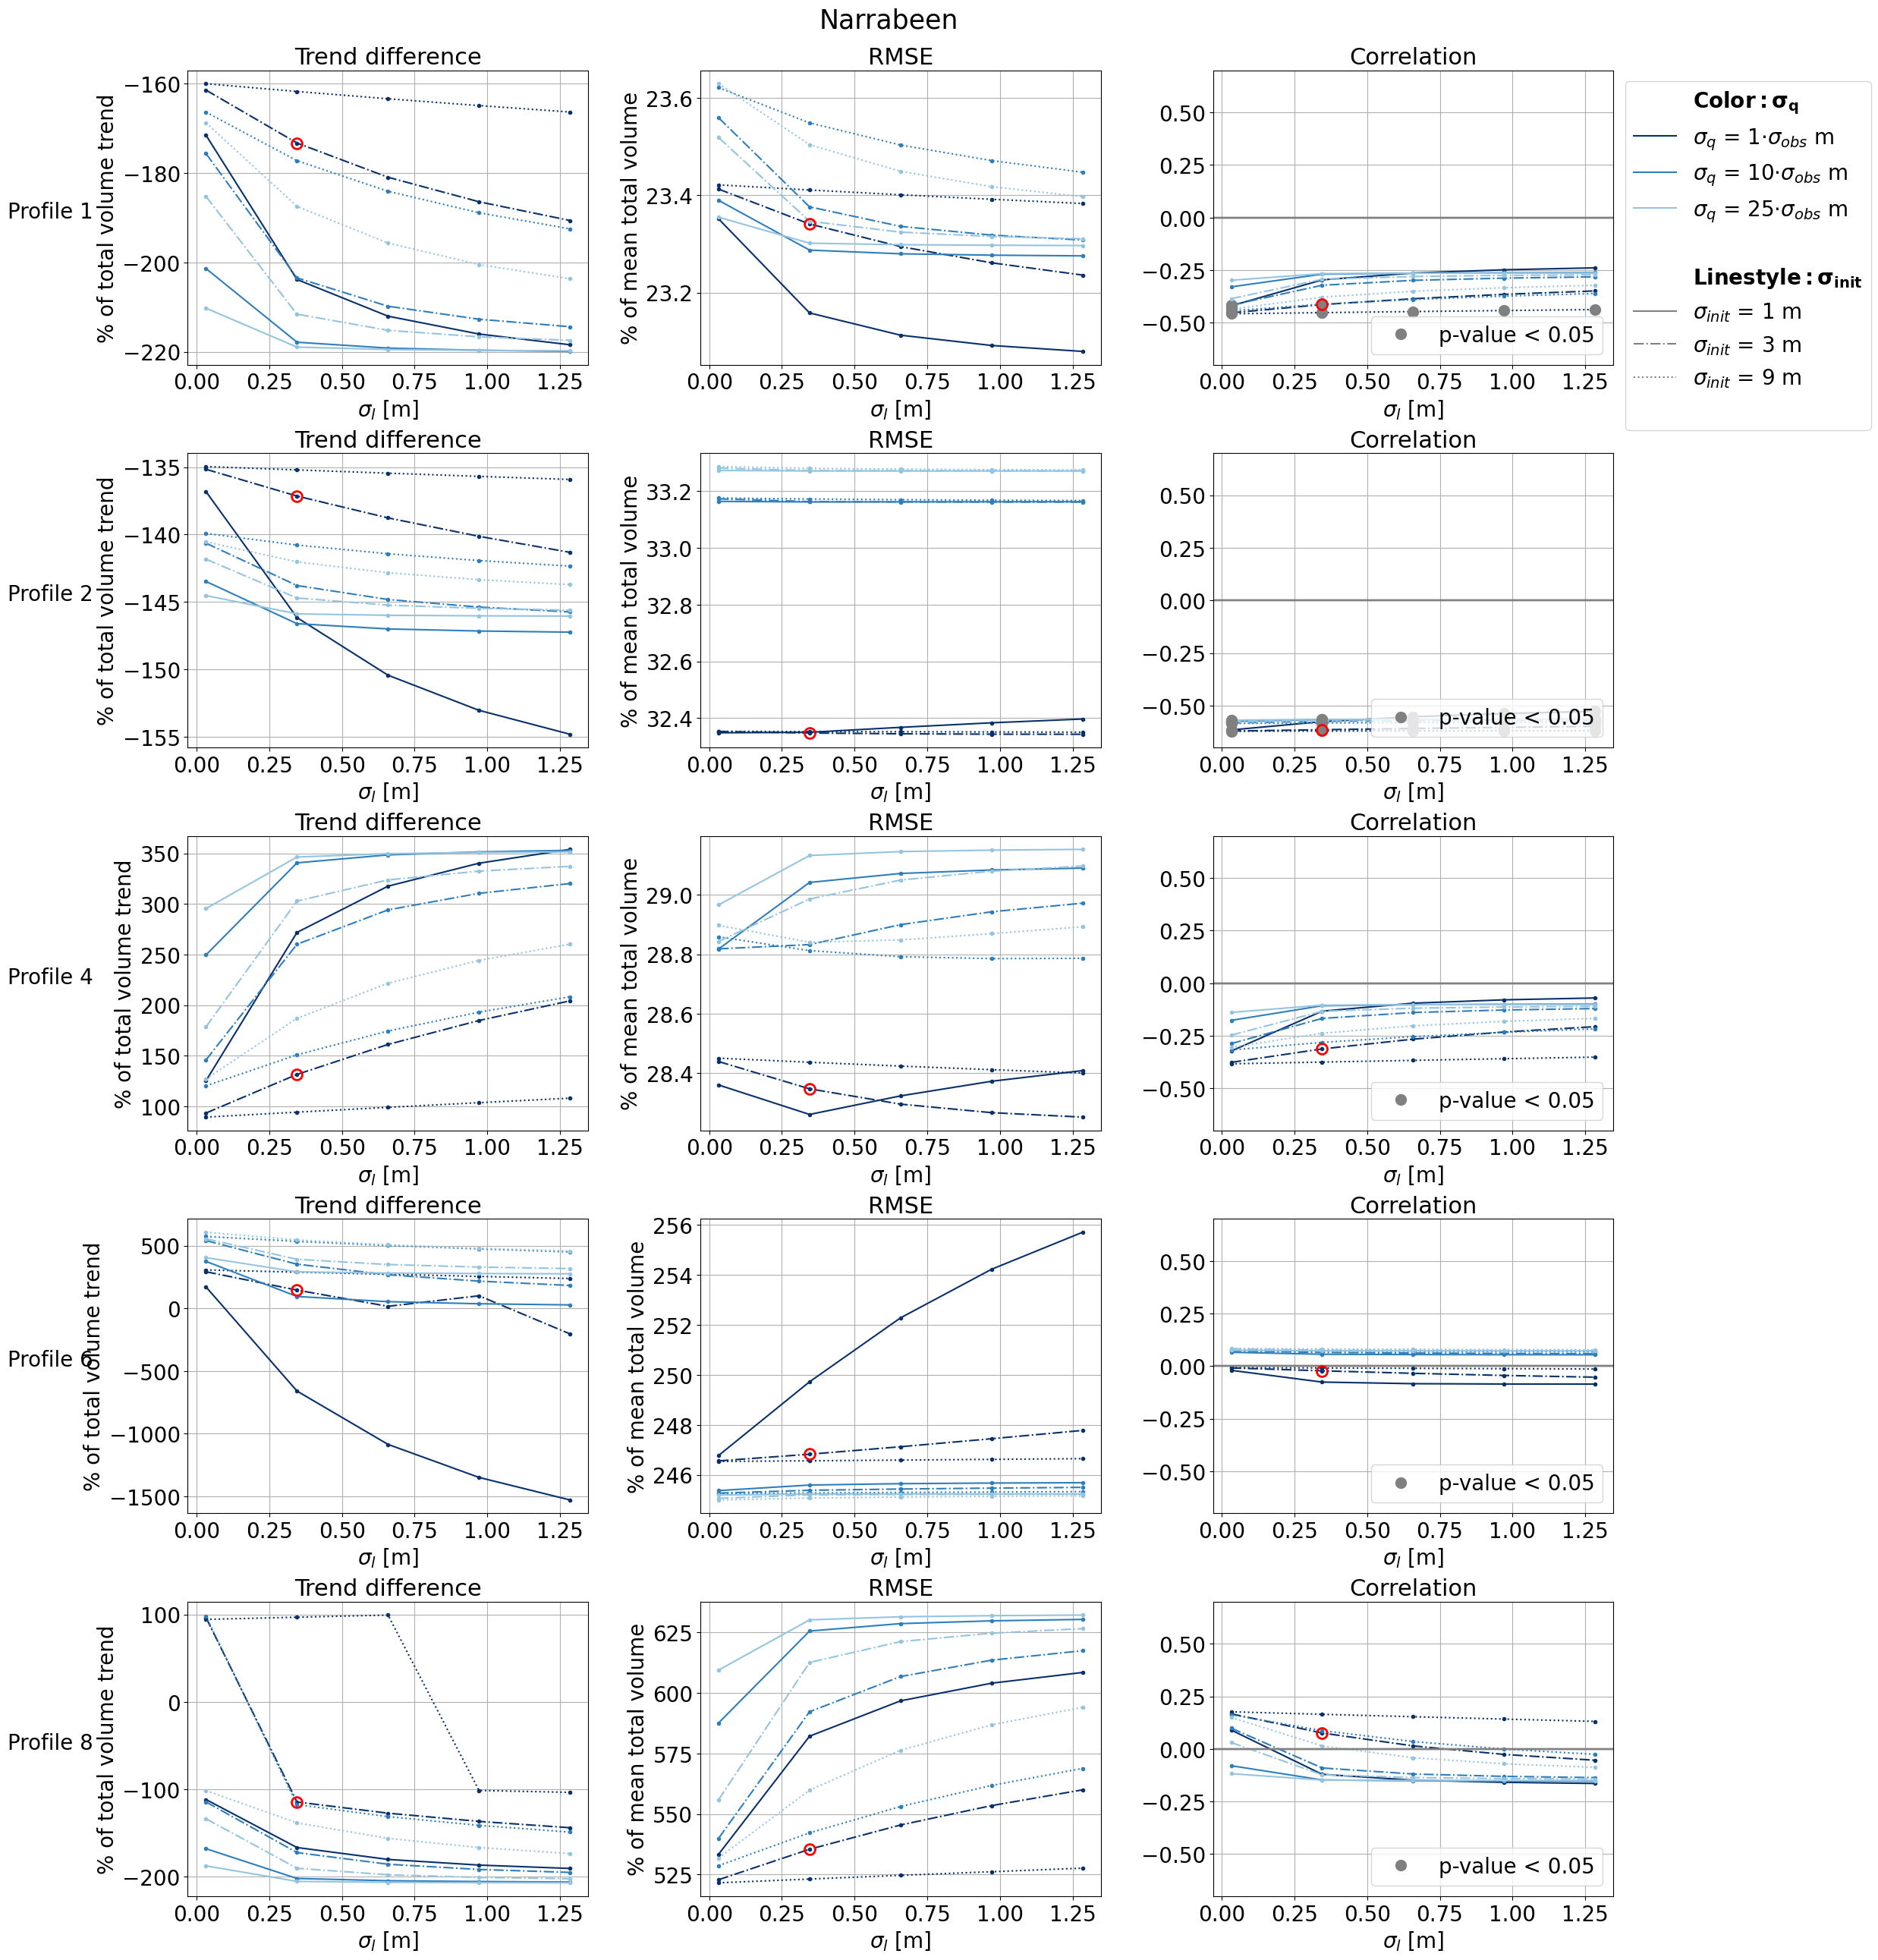

In [35]:
idx_selected = 4 # index of the parameters selected for validation

fig, axs = plt.subplots(5,3, figsize=(20,25))
fig.tight_layout()
fig.subplots_adjust(hspace=.3, wspace=.28)

# Relative trend differences (% of total volume trend from validation data)
plot_vol_stats(axs[0,0], trend_diff_perc, area='PF1', ylabel='% of total volume trend', title='Trend difference', plot_zero=False)
mark_selected_param(axs[0,0], idx_selected, trend_diff_perc['PF1'])

plot_vol_stats(axs[1,0], trend_diff_perc, area='PF2', ylabel='% of total volume trend', title='Trend difference', plot_zero=False)
mark_selected_param(axs[1,0], idx_selected, trend_diff_perc['PF2'])

plot_vol_stats(axs[2,0], trend_diff_perc, area='PF4', ylabel='% of total volume trend', title='Trend difference', plot_zero=False)
mark_selected_param(axs[2,0], idx_selected, trend_diff_perc['PF4'])

plot_vol_stats(axs[3,0], trend_diff_perc, area='PF6', ylabel='% of total volume trend', title='Trend difference', plot_zero=False)
mark_selected_param(axs[3,0], idx_selected, trend_diff_perc['PF6'])

plot_vol_stats(axs[4,0], trend_diff_perc, area='PF8', ylabel='% of total volume trend', title='Trend difference', plot_zero=False)
mark_selected_param(axs[4,0], idx_selected, trend_diff_perc['PF8'])

# Relative RMSE (% of the mean of the total volume)
plot_vol_stats(axs[0,1], rmse_perc, area='PF1', ylabel='% of mean total volume', title='RMSE')
mark_selected_param(axs[0,1], idx_selected, rmse_perc['PF1'])

plot_vol_stats(axs[1,1], rmse_perc, area='PF2', ylabel='% of mean total volume', title='RMSE')
mark_selected_param(axs[1,1], idx_selected, rmse_perc['PF2'])

plot_vol_stats(axs[2,1], rmse_perc, area='PF4', ylabel='% of mean total volume', title='RMSE')
mark_selected_param(axs[2,1], idx_selected, rmse_perc['PF4'])

plot_vol_stats(axs[3,1], rmse_perc, area='PF6', ylabel='% of mean total volume', title='RMSE')
mark_selected_param(axs[3,1], idx_selected, rmse_perc['PF6'])

plot_vol_stats(axs[4,1], rmse_perc, area='PF8', ylabel='% of mean total volume', title='RMSE')
mark_selected_param(axs[4,1], idx_selected, rmse_perc['PF8'])

ylim_corr = [-.7,.7]
plot_vol_stats(axs[0,2], corr_df.T, area='PF1', ylabel='', title='Correlation', corr=True, plot_zero=True, ylim=ylim_corr)
mark_selected_param(axs[0,2], idx_selected, corr_df.T['PF1'])

plot_vol_stats(axs[1,2], corr_df.T, area='PF2', ylabel='', title='Correlation', corr=True, plot_zero=True, ylim=ylim_corr)
mark_selected_param(axs[1,2], idx_selected, corr_df.T['PF2'])

plot_vol_stats(axs[2,2], corr_df.T, area='PF4', ylabel='', title='Correlation', corr=True, plot_zero=True, ylim=ylim_corr)
mark_selected_param(axs[2,2], idx_selected, corr_df.T['PF4'])

plot_vol_stats(axs[3,2], corr_df.T, area='PF6', ylabel='', title='Correlation', corr=True, plot_zero=True, ylim=ylim_corr)
mark_selected_param(axs[3,2], idx_selected, corr_df.T['PF6'])

plot_vol_stats(axs[4,2], corr_df.T, area='PF8', ylabel='', title='Correlation', corr=True, plot_zero=True, ylim=ylim_corr)
mark_selected_param(axs[4,2], idx_selected, corr_df.T['PF8'])

plot_legend(axs[0,1], c_list, ls_list, factors, std_init_values)
fig.suptitle('Narrabeen', y=1.02, fontsize=25);

axs[0,0].text(-.45,.5, f'Profile 1', transform=axs[0,0].transAxes, fontsize=20)
axs[1,0].text(-.45,.5, f'Profile 2', transform=axs[1,0].transAxes, fontsize=20)
axs[2,0].text(-.45,.5, f'Profile 4', transform=axs[2,0].transAxes, fontsize=20)
axs[3,0].text(-.45,.5, f'Profile 6', transform=axs[3,0].transAxes, fontsize=20)
axs[4,0].text(-.45,.5, f'Profile 8', transform=axs[4,0].transAxes, fontsize=20)

plt.savefig(f'{path_output}Narra_partun_volume_change_stats_allProfiles.png', dpi=300, bbox_inches='tight')

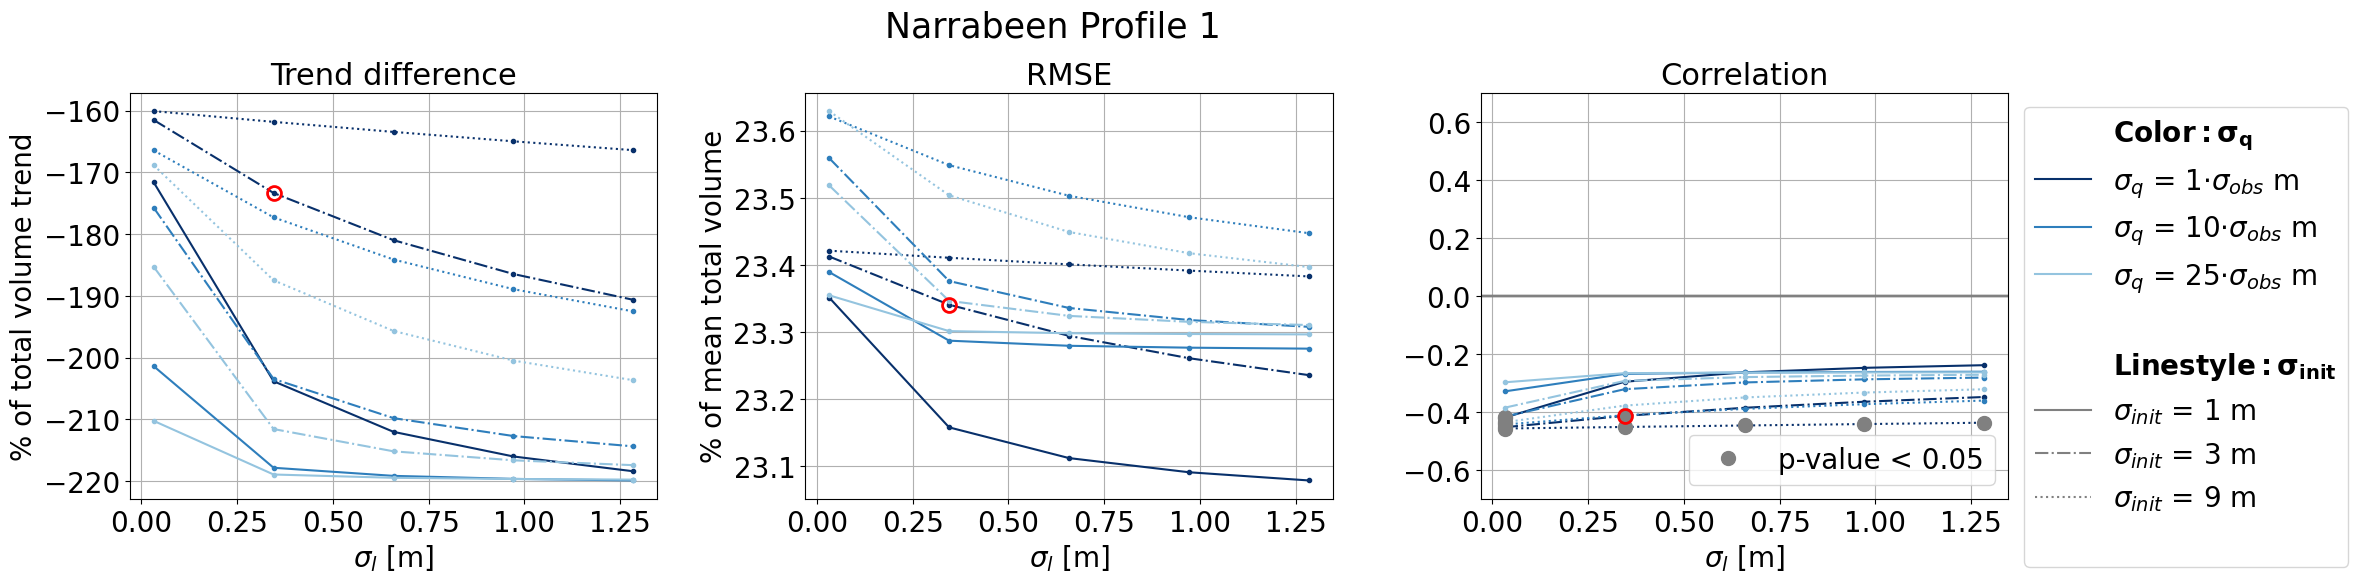

In [36]:
fig, axs = plt.subplots(1,3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.3, wspace=.28)

# Relative trend differences (% of total volume trend from validation data)
plot_vol_stats(axs[0], trend_diff_perc, area='PF1', ylabel='% of total volume trend', title='Trend difference', plot_zero=False)
mark_selected_param(axs[0], idx_selected, trend_diff_perc['PF1'])

# Relative RMSE (% of the mean of the total volume)
plot_vol_stats(axs[1], rmse_perc, area='PF1', ylabel='% of mean total volume', title='RMSE')
mark_selected_param(axs[1], idx_selected, rmse_perc['PF1'])

ylim_corr = [-.7,.7]
plot_vol_stats(axs[2], corr_df.T, area='PF1', ylabel='', title='Correlation', corr=True, plot_zero=True, ylim=ylim_corr)
mark_selected_param(axs[2], idx_selected, corr_df.T['PF1'])

plot_legend(axs[1], c_list, ls_list, factors, std_init_values)
fig.suptitle('Narrabeen Profile 1', y=1.1, fontsize=25);

plt.savefig(f'{path_output}Narra_partun_volume_change_stats_onlyProfile1.png', dpi=300, bbox_inches='tight')

### Elevation changes

In [37]:
def plot_elev_stats(ax, stats_data, stats_varname, ylabel, title, corr=False, plot_zero=False, ylim=None):
    for f, factor in enumerate(factors):
        for g, std_init in enumerate(std_init_values):
            ax.plot(stats_data.sigma_l, stats_data[stats_varname].loc[{'factors':factor, 'std_init':std_init}].median(dim='lon'), ls=ls_list[g], c=c_list[f], marker='.')
            if corr:
                pvalues_box = np.where(stats_data.pvalue.loc[{'factors':factor, 'std_init':std_init}].mean(dim='lon') < 0.05)[0]
                ax.plot(stats_data.sigma_l[idx[pvalues_box]], stats_data.corr.loc[{'factors':factor, 'std_init':std_init}].median(dim='lon')[idx[pvalues_box]], 
                marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')
                ax.legend(handles=[Line2D([0], [0], marker='o', lw=0, ms=10, color='grey', label='p-value < 0.05')], loc='lower right')
            if ylim is not None:
                ax.set_ylim(ylim)
            if plot_zero:
                ax.axhline(y=0, color='grey')
    ax.set_xlabel(r'$\sigma_{obs}$ [m]')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid()

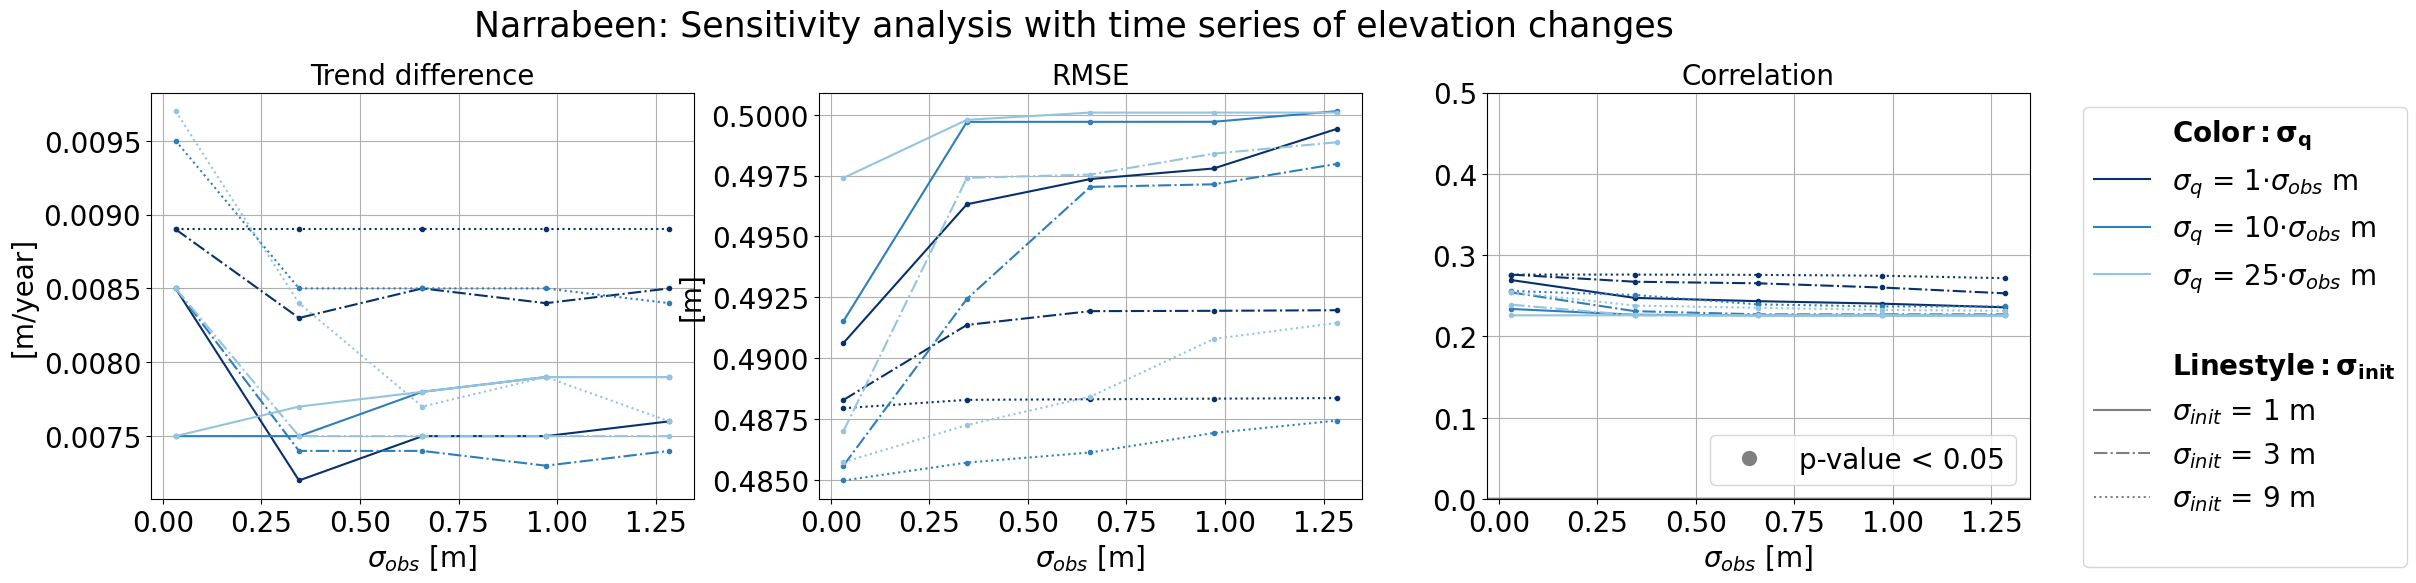

In [38]:
fig, axs = plt.subplots(1,3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.3, wspace=.23)

plot_elev_stats(axs[0], all_stats, 'trend_diff', ylabel='[m/year]', title='Trend difference', plot_zero=False)

# axs[0].text(-.45,.5, f'Entire\ncoastline', transform=axs[0].transAxes, fontsize=20)

# ylim_rmse = [.32,.33]
plot_elev_stats(axs[1], all_stats, 'rmse', ylabel='[m]', title='RMSE') #, ylim=ylim_rmse)

ylim_corr = [0,.5]
plot_elev_stats(axs[2], all_stats, 'corr', ylabel='', title='Correlation', corr=True, plot_zero=True, ylim=ylim_corr)

plot_legend(axs[1], c_list, ls_list, factors, std_init_values)
fig.suptitle('Narrabeen: Sensitivity analysis with time series of elevation changes', y=1.1, fontsize=25);

plt.savefig(f'{path_output}Narra_partun_elev_change_stats.png', dpi=300, bbox_inches='tight')